<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Assignment 2</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h1></h1>
    <h3><i>Abstract</i></h3>
    <p>
    Abstrac here.
    <small style="margin-left: 1em">[1]</small>
    </p>
    <p>
    In this assignment, we will explore the dataset, and perform ...
    </p>
    <img src="./figures/cover.jpg" width="50%">
</center>

<h1>The Data</h1>

<p>
The dataset which we'll look at in this assignment, has been supplied by Charmaine Yung <sup><small>[1]</small></sup>, from one of the papers <sup><small>[2]</small></sup> she contributed to.
</p>

<p>
It's data collected at ... using ...,
</p>

<p>
We'll explore the dataset, and create a neural network model that'll hopefully tell us a bit more about how the abundance of bacteria is affected by the temperature, seasons, etc.
</p>

In [ ]:
#! This is code from the previous assignment (with some modifications).

#####################################
#       You might need to restart   #
#           the kernel after        #
#           running this cell.      #
#####################################

## Detect environment

try:
    import google.colab # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

## Grading?

I_AM_GRADING = False

## Clone repository and download dependencies
## (assumes using Conda if not in Google Colab)

if IN_COLAB:
    None
    !git clone https://github.com/jonassterud/OCES5303_A2.git
    !cp -r OCES5303_A2/* .
    %pip install -q -r ./requirements.txt
else:
    None
    %conda install -c conda-forge -c pytorch -qq --file ./requirements.txt

Channels:
 - conda-forge
 - pytorch
 - defaults
Platform: linux-64
Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [167]:
## Imports

import numpy as np
import pandas as pd
import plotly.io as pio
import plotly.express as px
import matplotlib.pyplot as plt
import torch
import random

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer, SplineTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, r2_score

from torch import nn
from skorch import NeuralNetRegressor

## Configuration

pio.templates.default = "plotly_dark"
seed = int(9000 + 0.0001)
_ = random.seed(seed)
_ = np.random.seed(seed)
_ = torch.manual_seed(seed)
_ = torch.backends.cudnn.deterministic = True
_ = torch.backends.cudnn.benchmark = False

## Colors

RED = "#FF6200"
RED_TRANSPARENT = "#FF6200A7"
GREEN = "#00B755"
GREEN_TRANSPARENT = "#00B755A7"
BLUE = "#0048FF"
BLUE_TRANSPARENT = "#0048FFA7"
GREY = "#959595"
GREY_TRANSPARENT = "#959595A7"


<h1>Parsing</h1>

<p>
The dataset, which contains 151 samples, has the following variables:
</p>

<ul>
    <li><code>YearDay</code>: Day of the year</li>
    <li><code>Bacteria_abundance</code>: Number of bacteria cells</li>
    <li><code>Projected_Daily_Insolation</code>: Solar heating</li>
    <li><code>Temp</code>: Sea Temperature (℃)</li>
    <li><code>MLLW</code>: Low of the tide TODO?</li>
    <li><code>Salinity</code>: Practical Salinity (PSU)</li>
    <li><code>Oxygen_Saturation</code>: Ratio of concentration of oxygen versus maximum possible concentration of oxygen (%)</li>
    <li><code>pH</code>: pH level.</li>
    <li><code>DIC</code>: Dissolved inorganic carbon</li>
    <li><code>Chlorophyll</code>: Amount of chlorophyll (mg/m³)</li>
    <li><code>NH4</code>: ...</li>
    <li><code>NO2.NO3</code>: ...</li>
    <li><code>PO4</code>: Phosphate (ppm)</li>
    <li><code>SiO4</code>: Dissolved silicate (µM)</li>
    
</ul>

<p>
We load the data from a <code>.txt</code> file into a Pandas <code>DataFrame</code>.
Here, we'll also drop the <code>SampleID</code> variable, since this is just an identifier for the sample, and won't be any useful for our model.
</p>

<p>
Additionaly, we see that the values of <code>YearDay</code> is linear. In reality, years are, of course, cyclical. We'll handle this later.
</p>

In [168]:
df = pd.read_csv("./data/PIDweekly_env_data.txt", sep=r"\s+")
df["YearDay"] = df["YearDay"].astype(float) 
df = df.drop(columns=["SampleID"])

<h1>Split Data</h1>

<p>
First, we'll split the data up into two disjoint subsets: train and test.
</p>

<p>
We'll use the training set for explorative data analysis and training our neural network models.
</p>

<p>
To avoid overfitting (i.e. not being able to generalize), we'll use cross validation to get an unbiased performance, both when calculating the performance metrics of our models and when choosing hyperparameters/pipeline approaches. Finally, to get a totally unbiased performance metric of our final model, we'll check the generalization error on our test set.
</p>

<p>
We'll do a 60-40% split for our training and test set - the reason for this is that due to the relatively low amount of samples, calculating the generalization error was not representative when the test set was too small, and the training didn't see to get too affected by a lower number of samples (compared to e.g. a more standard 80-20% split).
</p>

In [169]:
## Split data (60%, 40%)

X = df.drop(columns = ["Bacteria_abundance"])
y = df["Bacteria_abundance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.60, random_state = seed)

## Combined train set (for visualization)

Xy_train = pd.concat([X_train, y_train], axis=1)

<h1>Exploratory Data Analysis</h1>

<p>
To see if there's any obvious patterns between time and the bacteria abunduance, we'll plot <code>Bacteria_abunduance</code> with <code>YearDay</code> together with a polynomial trendline.
</p>

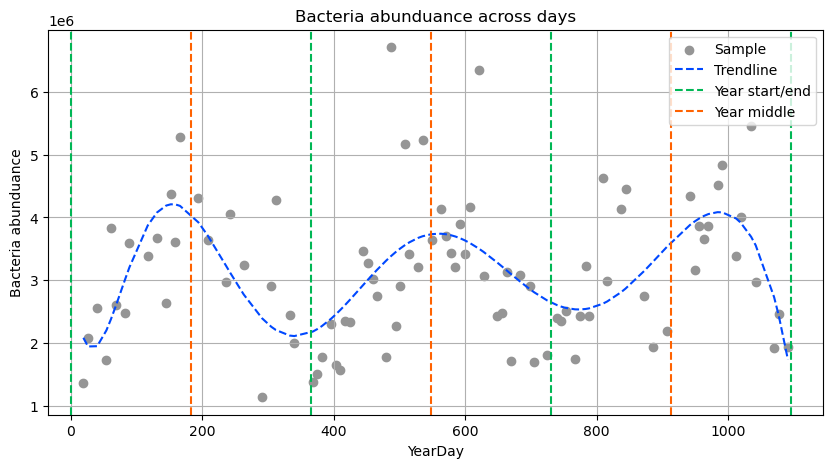

In [170]:
## Sort data and create polynomial trendline

df_viz = Xy_train.sort_values(by="YearDay")
poly = np.poly1d(np.polyfit(df_viz["YearDay"], df_viz["Bacteria_abundance"], 9))

## Display data and trendline

plt.figure(figsize=(10, 5))
plt.scatter(df_viz["YearDay"], df_viz["Bacteria_abundance"], c=GREY, label="Sample")
plt.plot(df_viz["YearDay"], poly(df_viz["YearDay"]), c=BLUE, ls="--", label="Trendline")

plt.axvline(x=365*0, color=GREEN, ls='--', label="")
plt.axvline(x=365*1, color=GREEN, ls='--', label="")
plt.axvline(x=365*2, color=GREEN, ls='--', label="")
plt.axvline(x=365*3, color=GREEN, ls='--', label="Year start/end")

plt.axvline(x=365*0+182.5, color=RED, ls='--', label="")
plt.axvline(x=365*1+182.5, color=RED, ls='--', label="")
plt.axvline(x=365*2+182.5, color=RED, ls='--', label="Year middle")

plt.xlabel("YearDay")
plt.ylabel("Bacteria abunduance")
plt.title(f"Bacteria abunduance across days")
plt.legend()
plt.grid()
plt.show()

<p>
We see that the bacteria abunduance seems to approximately follow a sinusoid, with minimum values around the start/end of each year and maximum values around the middle of each year. We're dealing with both a cyclic feature (<code>YearDay</code>) and a seemingly cyclic target variable (<code>Bacteria_abunduance</code>).
</p>

<h1>Cyclic Features</h1>

<p>
As previously mentioned, we're dealing with some cyclic data.
We have the <code>YearDay</code> variable, which tells us which day of the year the observation happened. The values here are in their linear form, so in order to make them cyclic, we have to transform them.
</p>

<p>
There's a variety of transformation methods for this, we'll use both (and choose the best performing) a periodic spline transformer and "sinus and cosinus" transformations. <sup><small>[3]</small></sup>
</p>

In [171]:
## Create spline transformer

_t_cyclic_spline = SplineTransformer(
    degree=365,
    n_knots=365 + 1, # Include bias term (+ 1)
    knots=np.linspace(0, 365, 365 + 1).reshape(365 + 1, 1),
    extrapolation="periodic",
    include_bias=True,
)

t_cyclic_spline = ColumnTransformer(
    [("cyclic", _t_cyclic_spline, ["YearDay"])],
    remainder="passthrough",
    verbose_feature_names_out=False
)

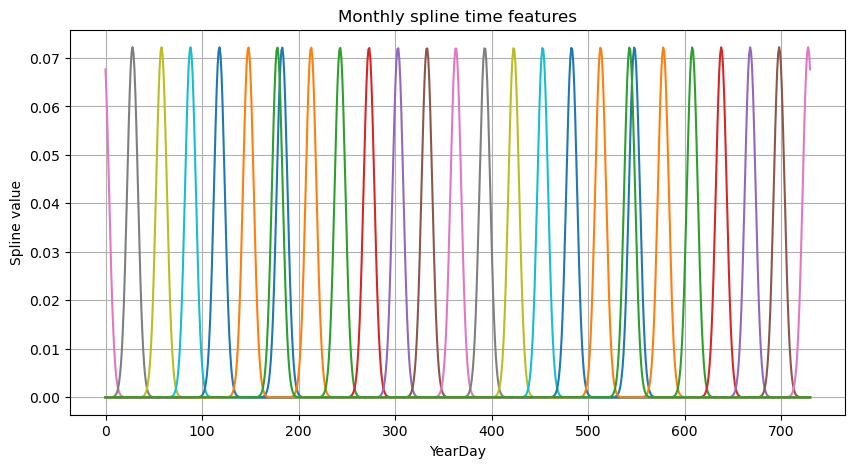

In [172]:
## Visualize cyclic ability

df_time = pd.DataFrame(
    np.linspace(0, 365 * 2, 365 * 2).reshape(-1, 1),
    columns=["YearDay"],
)

df_cyclic_features = t_cyclic_spline.set_output(transform="pandas").fit_transform(df_time)
df_cyclic_features["YearDay"] = df_time["YearDay"]

plt.figure(figsize=(10, 5))
for i in range(0, 365, 30):
    plt.plot(df_cyclic_features["YearDay"], df_cyclic_features[f"YearDay_sp_{i}"])
plt.xlabel("YearDay")
plt.ylabel("Spline value")
plt.title(f"Monthly spline time features")
plt.grid()
plt.show()

In [173]:
## Create trigonmetric transformer

_t_cyclic_sin = FunctionTransformer(lambda x: np.sin(x / 365 * 2 * np.pi))
_t_cyclic_cos = FunctionTransformer(lambda x: np.cos(x / 365 * 2 * np.pi))

t_cyclic_trig = ColumnTransformer(
    [("cyclic_sin", _t_cyclic_sin, ["YearDay"]), ("cyclic_cos", _t_cyclic_cos, ["YearDay"])],
    remainder="passthrough",
    verbose_feature_names_out=True
)

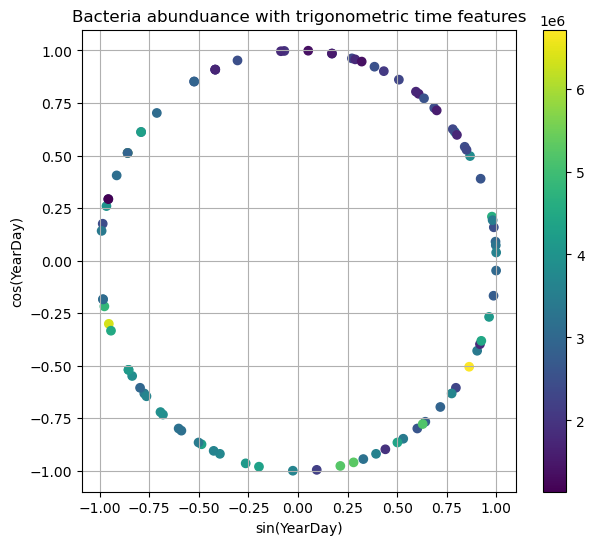

In [174]:
## Visualize cyclic ability

df_cyclic_features = t_cyclic_trig.set_output(transform="pandas").fit_transform(Xy_train)

plt.subplots(figsize=(7, 6))
plt.scatter(df_cyclic_features["cyclic_sin__YearDay"], df_cyclic_features["cyclic_cos__YearDay"], c=df_cyclic_features["remainder__Bacteria_abundance"])
plt.xlabel("sin(YearDay)")
plt.ylabel("cos(YearDay)")
plt.title(f"Bacteria abunduance with trigonometric time features")
plt.colorbar()
plt.grid()
plt.show()

<h1>Feature Selection</h1>

<p>
Since we're only using one feature, let's remove the other features.
</p>

In [175]:
# Filter features transformer
features = [
    "Projected_Daily_Insolation",
    "Temp",
    "MLLW",
    "Salinity",
    "Oxygen_Saturation",
    "pH",
    "DIC",
    "Chlorophyll",
    "NH4",
    "NO2.NO3",
    "PO4",
    "SiO4",
]

t_drop = ColumnTransformer(
    [("drop", "drop", features)],
    remainder = "passthrough",
    verbose_feature_names_out = False,
)

<h1>Tensors</h1>

<p>
Now, let's create a transformer that can turn our <code>DataFrame</code> into something more suitable for Pytorch - tensors.
</p>

In [176]:
## Transformation

def _add_tensors(data):
    data_c = data.copy()
    data_c = torch.from_numpy(np.array(data_c)).type(torch.float32)

    return data_c

t_tensors = FunctionTransformer(func=_add_tensors)

<h1>Neural Network</h1>

<p>
We're now ready to define our neural networks.
</p>

<p>
We'll try, among others, a simple neural network with four hidden layers (with affine transformations) together with a tanh activation function.
Networks with larger/smaller amount of hidden layers and other activation functions were tried aswell, but this configuration yielded the best results.
</p>

<p>
We'll also try a "Recurrent Neural Network" (RNN), which is a deep learning model designed for sequential (which includes cyclic-) data. The "memory" part of our RNN should hopefully pick up on the sinusoid like shape of our target variable. <sup><small>[4]</small></sup>
</p>

<p>
Additionaly, we'll try a "Long Short-Term Memory" (LSTM) neural network, which is a type of RNN, but also includes a "forget" component, which decides what information to discard from the previous state. <sup><small>[4]</small></sup>
</p>

In [177]:
## Neural Network (NN)

class Layer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.hidden = nn.Linear(in_features, out_features)
        self.activate = nn.Tanh()

    def forward(self, x):
        out = self.hidden(x)
        out = self.activate(out)

        return out


class NeuralNetwork(nn.Module):
    def __init__(self, in_features, factor=64):
        super(NeuralNetwork, self).__init__()

        self.i2h = Layer(in_features, factor)
        self.h1 = Layer(factor, factor // 2)
        self.h2 = Layer(factor // 2, factor // 4)
        self.h3 = Layer(factor // 4, factor // 8)
        self.h4 = Layer(factor // 8, factor // 16)
        self.h2o = nn.Linear(factor // 16, 1)

    def forward(self, x):
        out = self.i2h(x)
        out = self.h1(out)
        out = self.h2(out)
        out = self.h3(out)
        out = self.h4(out)
        out = self.h2o(out)

        return out

In [178]:
## Recurrent Neural Network (RNN)

class RecurrentNeuralNetwork(nn.Module):
    def __init__(self, in_features, hidden_size=4, num_layers=1, dropout=0.0):
        super(RecurrentNeuralNetwork, self).__init__()

        self.rnn = nn.RNN(in_features, hidden_size, num_layers=num_layers, dropout=dropout)
        self.decoder = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(0) # add seq_len

        out, hidden = self.rnn(x)
        out = self.decoder(out[-1, :])

        return out

In [179]:
## Long Short-Term Memory (LSTM) network

class LongShortTermMemory(nn.Module):
    def __init__(self, in_features, hidden_size=4, num_layers=1, dropout=0.0):
        super(LongShortTermMemory, self).__init__()

        self.lstm = nn.LSTM(in_features, hidden_size, num_layers=num_layers, dropout=dropout)
        self.decoder = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(0) # add seq_len

        out, hidden = self.lstm(x)
        out = self.decoder(out[-1, :])

        return out

<h1>Metrics</h1>

<p>
We need a way to evaluate the performance of our models, for this we'll calculate three different metrics:
</p>

<ul>
    <li>Mean Absolute Percentage Error (MAPE): The "forecasting accuracy", tells us the average distance between predictions and actual values.</li>
    <li>Median Absolute Error (MedAE): Calculates the differences between predictions and actual values, and returns the median.</li>
    <li>Coefficient of determination (R²): Our scoring metric, tells us the proprotion of variance explained by our model.</li>
</ul>

<p>
The metrics have the ability to be cross-validated (i.e. calculating the average over multipile folds) to get an unbiased performance metric for our model.
</p>

In [180]:
class Metrics:
    def __init__(self, model, X, y, cross_validated=True):
        self.cross_validated = cross_validated
        self.measurements = [
            ["Mean Absolute Percentage Error", "neg_mean_absolute_percentage_error", mean_absolute_percentage_error],
            ["Median Absolute Error", "neg_median_absolute_error", median_absolute_error],
            ["R2", "r2", r2_score],
        ]

        if (self.cross_validated):
            self._metrics = list(map(lambda kv: (
                kv[0],
                np.mean(cross_val_score(model, X, y, scoring=kv[1]
            ))), self.measurements))
        else:
            self._metrics = list(map(lambda kv: (
                kv[0],
                kv[2](y, model.predict(X))
            ), self.measurements))

    def __repr__(self):
        if self.cross_validated: return '\n'.join(map(lambda kv: f"{kv[0]} (CV): {np.abs(kv[1]):.5f}", self._metrics))
        else: return '\n'.join(map(lambda kv: f"{kv[0]}: {np.abs(kv[1]):.5f}", self._metrics))

<h1>Pipeline and Hyperparameters</h1>

<p>
Next, we'll define a pipeline, and a grid of parameters, to test our various neural networks and configurations.
</p>

<p>
We're testing all of our neural networks, together with various scaling methods, cyclic transformations, and various hyperparameters.
</p>

<p>
Additionaly, we're also finding the best model <i>without</i> any cyclic transformations, to see the effect of that. 
</p>

In [ ]:
pipeline = Pipeline([
    ("drop", t_drop.set_output(transform="pandas")),
    ("cyclic", "passhtrough"),
    ("scale", "passhtrough"),
    ("tensors", t_tensors),
    ("regression", TransformedTargetRegressor()),
])

def regressor(network: str, **args):
    match network:
        case "NN":
            return NeuralNetRegressor(
                NeuralNetwork(args.get("in_features"), args.get("factor")),
                max_epochs=200,
                lr=0.1,
                iterator_train__shuffle=True,
                verbose=0,
            )
        case "RNN":
            return NeuralNetRegressor(
                RecurrentNeuralNetwork(args.get("in_features"), args.get("hidden_size"), args.get("num_layers"), args.get("dropout")),
                max_epochs=200,
                lr=0.01,
                iterator_train__shuffle=True,
                verbose=0,
            )
        case "LSTM":
            return NeuralNetRegressor(
                LongShortTermMemory(args.get("in_features"), args.get("hidden_size"), args.get("num_layers"), args.get("dropout")),
                max_epochs=200,
                lr=0.1,
                iterator_train__shuffle=True,
                verbose=0,
            )

params_wide = [
    # Passhtrough; StandardScaler, MinMaxScaler; NN, RNN
    {
        "cyclic": ["passthrough"],
        "scale": [StandardScaler(), MinMaxScaler()],
        "regression__transformer": [StandardScaler(), MinMaxScaler()],
        "regression__regressor": [
            regressor("NN", in_features=1, factor=64),
            regressor("NN", in_features=1, factor=128),
            regressor("RNN", in_features=1, hidden_size=64, num_layers=1, dropout=0.0),
            regressor("RNN", in_features=1, hidden_size=64, num_layers=2, dropout=0.2),
            regressor("RNN", in_features=1, hidden_size=64, num_layers=4, dropout=0.0),
            regressor("RNN", in_features=1, hidden_size=64, num_layers=8, dropout=0.2),
            regressor("LSTM", in_features=1, hidden_size=64, num_layers=1, dropout=0.0),
            regressor("LSTM", in_features=1, hidden_size=64, num_layers=2, dropout=0.2),
            regressor("LSTM", in_features=1, hidden_size=64, num_layers=4, dropout=0.0),
            regressor("LSTM", in_features=1, hidden_size=64, num_layers=8, dropout=0.2),
        ]
    },
    # Spline features; StandardScaler, MinMaxScaler; NN, RNN
    {
        "cyclic": [t_cyclic_spline],
        "scale": [StandardScaler(), MinMaxScaler()],
        "regression__transformer": [StandardScaler(), MinMaxScaler()],
        "regression__regressor": [
            regressor("NN", in_features=365, factor=64),
            regressor("NN", in_features=365, factor=128),
            regressor("RNN", in_features=365, hidden_size=64, num_layers=1, dropout=0.0),
            regressor("RNN", in_features=365, hidden_size=64, num_layers=2, dropout=0.2),
            regressor("LSTM", in_features=365, hidden_size=64, num_layers=1, dropout=0.0),
            regressor("LSTM", in_features=365, hidden_size=64, num_layers=2, dropout=0.2),
        ]
    },
   # Trigonometric features; StandardScaler, MinMaxScaler; NN, RNN
   {
        "cyclic": [t_cyclic_trig],
        "scale": [StandardScaler(), MinMaxScaler()],
        "regression__transformer": [StandardScaler(), MinMaxScaler()],
        "regression__regressor": [
            regressor("NN", in_features=2, factor=64),
            regressor("NN", in_features=2, factor=128),
            regressor("RNN", in_features=2, hidden_size=32, num_layers=1, dropout=0.0),
            regressor("RNN", in_features=2, hidden_size=32, num_layers=2, dropout=0.2),
            regressor("LSTM", in_features=2, hidden_size=32, num_layers=1, dropout=0.0),
            regressor("LSTM", in_features=2, hidden_size=32, num_layers=2, dropout=0.2),
        ]
    },
]

params_narrow = [
    # Passhtrough; StandardScaler, MinMaxScaler; NN, RNN
    {
        "cyclic": ["passthrough"],
        "scale": [StandardScaler()],
        "regression__transformer": [StandardScaler()],
        "regression__regressor": [regressor("NN", in_features=1, factor=64)]
    },
   # Trigonometric features; StandardScaler, MinMaxScaler; NN, RNN
    {
        "cyclic": [t_cyclic_trig],
        "scale": [MinMaxScaler()],
        "regression__transformer": [StandardScaler()],
        "regression__regressor": [regressor("NN", in_features=2, factor=64)]
    },
]

params = params_narrow if I_AM_GRADING else params_wide

<p>
To get an unbiased result, i.e. pick a configuration that is able to generalize on new data, we'll use cross validation for our grid search. Due to the low number of samples, we'll split the data within each batch into just three folds (lower than the default). We're then training each model on each pair of folds, and evaluated on the extra fold.
</p>

<p>
The configuration which returned the best average R² score is picked as our final model.
</p>

<p>
This cross validation, ensures that we're not picking a configuration that is highly specialized to our training set, and will struggle to generalize to new and unseen data. This is an important step in an attempt to minimize "overfitting", which is when a model grows too complex, and struggles to capture the general patterns.
</p>

In [182]:
cv = KFold(n_splits=3, shuffle=True, random_state=seed)

## Grid search (on cyclic feature)

gscv_cyclic = GridSearchCV(pipeline, param_grid=params[1:], scoring="r2", cv=cv, n_jobs=1, verbose=1)
gscv_cyclic = gscv_cyclic.fit(X_train, t_tensors.transform(y_train).view(-1, 1))

model = gscv_cyclic.best_estimator_

## Grid search (on non-cyclic feature)

gscv_linear = GridSearchCV(pipeline, param_grid=params[0], scoring="r2", cv=cv, n_jobs=1, verbose=1)
gscv_linear = gscv_linear.fit(X_train, t_tensors.transform(y_train).view(-1, 1))

model_linear = gscv_linear.best_estimator_

Fitting 3 folds for each of 1 candidates, totalling 3 fits


Fitting 3 folds for each of 1 candidates, totalling 3 fits


In [183]:
## Print metrics

print(Metrics(model, X_train, t_tensors.transform(y_train).view(-1, 1), True))

Mean Absolute Percentage Error (CV): 0.24371
Median Absolute Error (CV): 504370.62500
R2 (CV): 0.27957


<p>
The best model based on this grid search turned out to be using trigonmetric features, a <code>MinMaxScaler</code> and the standard neural network with a factor of 64.
</p>

<p>
This was picked because it returned the best overall cross validated R² score.
</p>

<p>
On the full training dataset, it received a cross validated R² score of around <code>0.3</code>.
</p>

<h1>Loss</h1>

<p>
The R² score doesn't seem to be too impressive. Let's take a look at the training and validation loss across the epochs to see if we're encountering any obvious overfitting/underfitting.
</p>

In [197]:
def visualize_loss(model, prefix = ""):

    df_loss = pd.DataFrame(
        list(map(lambda v: [v["epoch"], v["train_loss"], v["valid_loss"]], model[-1].regressor_.history))
    ).rename(columns={ 0: "Epoch", 1: "Training loss", 2: "Validation loss"})

    plt.subplots(figsize=(10, 5))
    plt.plot(df_loss["Epoch"], df_loss["Training loss"], c=RED, label="Training loss")
    plt.plot(df_loss["Epoch"], df_loss["Validation loss"], c=BLUE, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{prefix} Training vs. validation loss")
    plt.legend()
    plt.grid()
    plt.show()

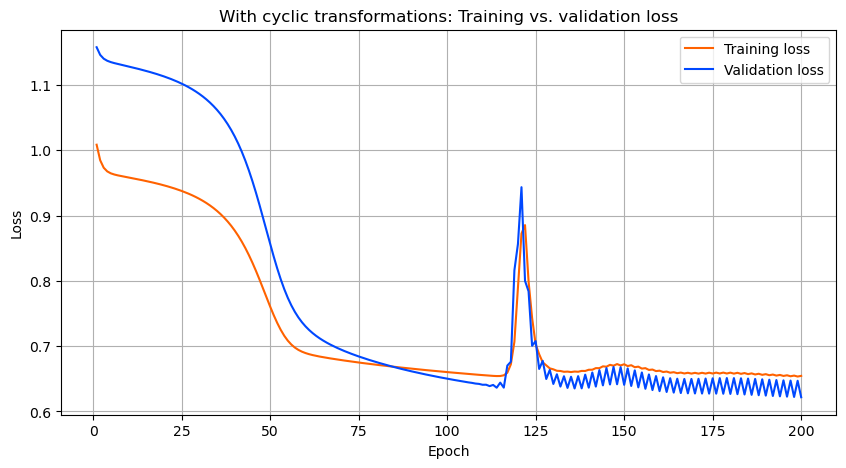

In [203]:
visualize_loss(model, "With cyclic transformations:")

<p>
Both the training loss and the validation loss follow approximately the same path, and they're both decreasing as time passes. This is a good sign, because it tells us that the model is learning the patterns in our training data and is able to generalize it to new (validation) data.
</p>

<p>
We also see a large sudden spike when the epoch is around 125 - this can indicate multipile things, e.g. too high learning rate, outlier(s), or something else. The model is able to recover from this sudden spike in loss however.
</p>

<p>
Let's also compare the loss for the model without the cyclic transformations.
</p>

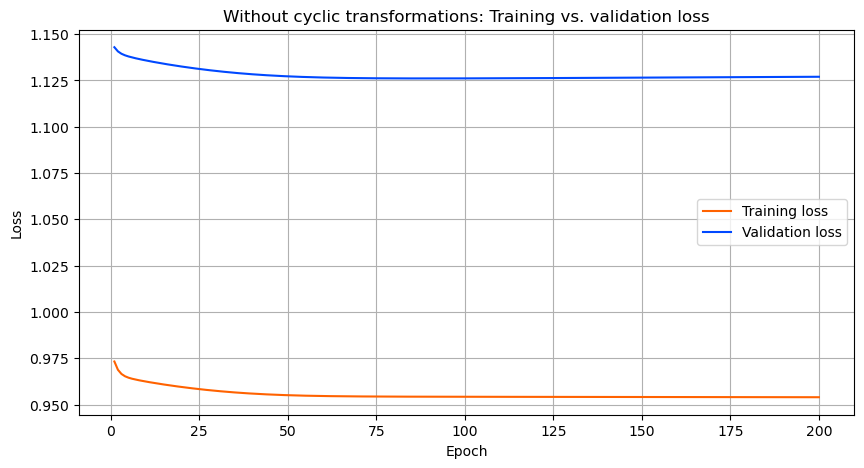

In [198]:
visualize_loss(model_linear, "Without cyclic transformations:")

<h1>Predictions and accuracy</h1>

In [205]:
def visualize_predictions(model, prefix = ""):
    for (name, X, y) in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        # Predict and calculate errors
        results_df = X.copy()
        results_df["target_actual"] = y.copy()
        results_df["target_predicted"] = model.predict(X)
        results_df["target_error"] = results_df["target_actual"] - results_df["target_predicted"]
        results_df["uplims"] = list(map(lambda v: int(v < 0), results_df["target_error"]))
        results_df["lolims"] = list(map(lambda v: int(v > 0), results_df["target_error"]))
        results_df["target_error_scaled"] = list(map(lambda v: np.abs(v), results_df["target_error"]))
        results_df = results_df.sort_values(by="YearDay")

        # Actual/predicted points
        plt.figure(figsize=(10, 5))
        plt.scatter(results_df["YearDay"], results_df["target_predicted"], color=RED, label="Predicted")
        plt.scatter(results_df["YearDay"], results_df["target_actual"], color=BLUE, label="Actual")

        # Actual trendline
        poly = np.poly1d(np.polyfit(results_df["YearDay"], results_df["target_actual"], 8))
        plt.plot(results_df["YearDay"], poly(results_df["YearDay"]), c=BLUE, ls="--", label="(Actual) Trendline")
        
        if (name == "Test"):
            # Error bars
            plt.errorbar(
                results_df["YearDay"], results_df["target_predicted"],
                yerr=results_df["target_error_scaled"],
                uplims=results_df["uplims"],
                lolims=results_df["lolims"],
                fmt=" ",
                ecolor="black",
                capsize=1,
                elinewidth=1
            )
        
        # Misc.
        plt.xlabel("Day of the year")
        plt.ylabel("Bacteria abundance")
        plt.legend()
        plt.title(f"{prefix} Predicted vs. actual - \"{name}\" dataset")
        plt.grid()
        plt.show()

        # Get metrics
        metrics = Metrics(model, X, t_tensors.transform(y).view(-1, 1), cross_validated=False)
        print(metrics)

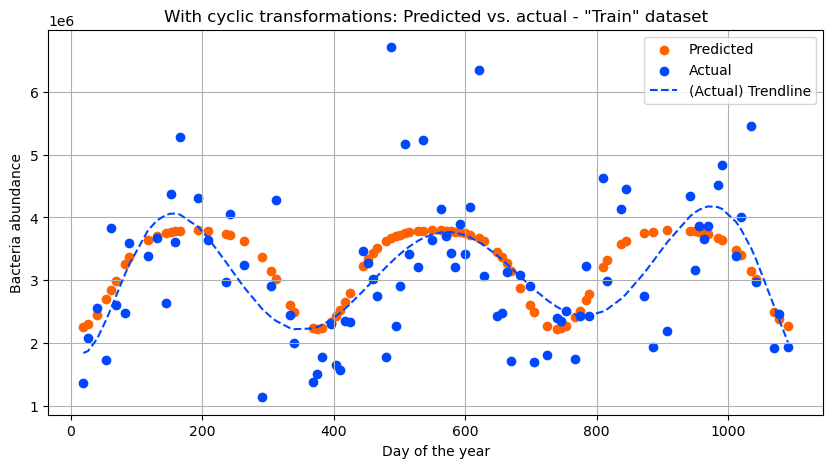

Mean Absolute Percentage Error: 0.24847
Median Absolute Error: 497843.68750
R2: 0.35323


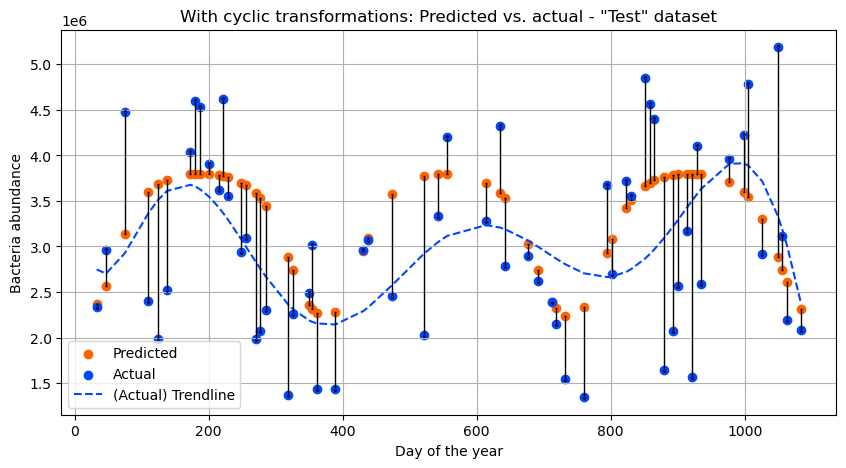

Mean Absolute Percentage Error: 0.31037
Median Absolute Error: 692514.12500
R2: 0.12079


In [206]:
visualize_predictions(model, "With cyclic transformations:")

<p>
We see that the predictions has resulted in a shape quite similar to for the training dataset, but it still struggles a bit to predict accurately due to the high variance between days.
</p>

<p>
For the test dataset, the effect of the variance is even more pronounced, with the R² score more than halfed compared to the training dataset.
However, the predictions still seem to follow the general shape of the data, the MAPE, tells us that on average, the predictions are 30% "away" from the actual values, which is more similar to what we got for the training dataset.
</p>

<p>
Let's compare it to the predictions for the model without the cyclic transformations.
</p>

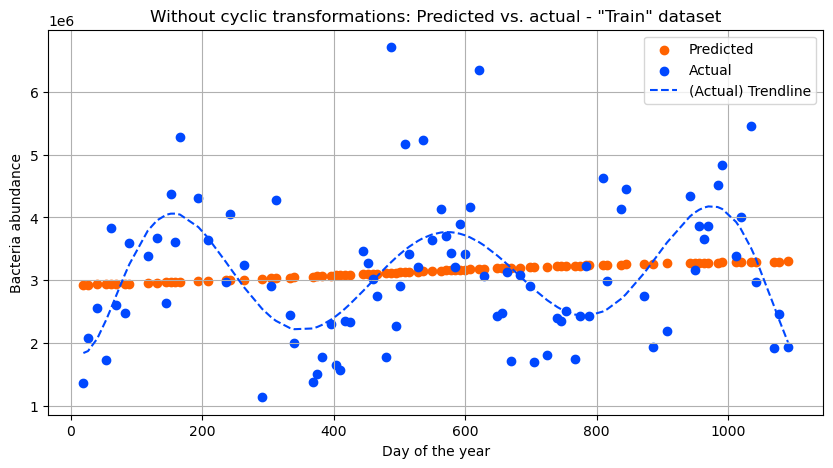

Mean Absolute Percentage Error: 0.33528
Median Absolute Error: 768511.75000
R2: 0.01142


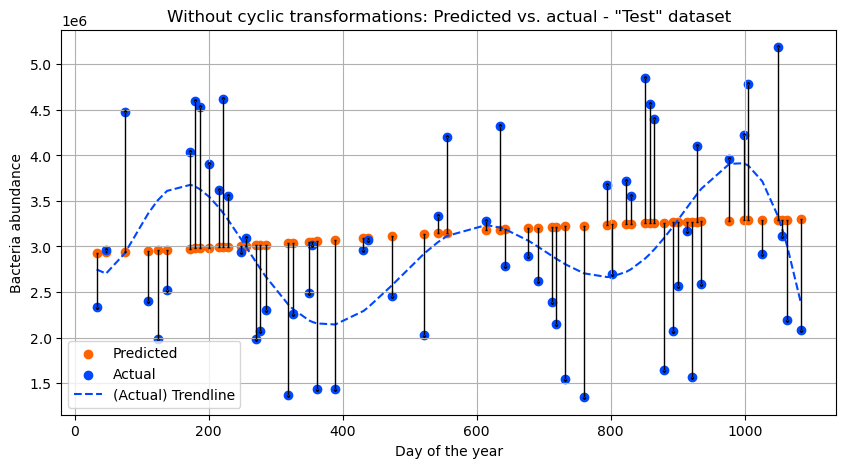

Mean Absolute Percentage Error: 0.34766
Median Absolute Error: 823658.25000
R2: 0.00916


In [202]:
visualize_predictions(model_linear, "Without cyclic transformations:")

Without any cyclic transformations, the model also struggles to see any cyclic patterns, and predicts a 

<p>
TODO: More conclusion, what could we do better, what did we learn, etc.
</p>

<h1>References</h1>

<p>[1] Yung Lab. (2026). <a href="https://www.charmaineyung.com/" target="_blank">https://www.charmaineyung.com/</a> (Accessed online: 30.03.2026)</p>
<p>[2] Ward, C., Yung, CM., Davis, K. et al. Annual community patterns are driven by seasonal switching between closely related marine bacteria. ISME J 11, 1412–1422 (2017). <a href="https://doi.org/10.1038/ismej.2017.4" target="_blank">https://doi.org/10.1038/ismej.2017.4</a> (Accessed online: 30.03.2026)</p>
<p>[3] scikit-learn developers. (2026). <a href="https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html" target="_blank">https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html</a> (Accessed online: 30.03.2026)</p>
<p>[4] Wikipedia contributors. Recurrent neural network. (2026). <a href="https://en.wikipedia.org/w/index.php?title=Recurrent_neural_network&oldid=1342698264" target="_blank">https://en.wikipedia.org/w/index.php?title=Recurrent_neural_network&oldid=1342698264</a> (Accessed online: 11.04.2026)</p>
<p>[4] Wikipedia contributors. Long short-term memory. (2026). <a href="https://en.wikipedia.org/w/index.php?title=Long_short-term_memory&oldid=1347877279" target="_blank">https://en.wikipedia.org/w/index.php?title=Long_short-term_memory&oldid=1347877279</a> (Accessed online: 12.04.2026)</p>